In [2]:
from pathlib import Path
import duckdb

PROJECT_ROOT = Path.cwd().parent
con = duckdb.connect(str(PROJECT_ROOT / "data" / "olist.duckdb"))

In [3]:
monthly_revenue = con.execute("""
    WITH order_revenue AS (
        SELECT
            o.order_id,
            DATE_TRUNC('month', o.order_purchase_timestamp) AS order_month,
            SUM(oi.price + oi.freight_value) AS order_total
        FROM olist_orders_dataset o
        JOIN olist_order_items_dataset oi ON o.order_id = oi.order_id
        WHERE o.order_status NOT IN ('canceled', 'unavailable')
        GROUP BY 1, 2
    ),
    monthly AS (
        SELECT
            order_month,
            SUM(order_total) AS revenue,
            COUNT(DISTINCT order_id) AS total_orders
        FROM order_revenue
        GROUP BY 1
    )
    SELECT
        order_month,
        revenue,
        total_orders,
        SUM(revenue) OVER (ORDER BY order_month) AS cumulative_revenue,
        LAG(revenue) OVER (ORDER BY order_month) AS prev_month_revenue,
        ROUND(
            (revenue - LAG(revenue) OVER (ORDER BY order_month))
            / NULLIF(LAG(revenue) OVER (ORDER BY order_month), 0) * 100, 2
        ) AS mom_growth_pct
    FROM monthly
    ORDER BY order_month
""").df()

monthly_revenue

,order_month,revenue,total_orders,cumulative_revenue,prev_month_revenue,mom_growth_pct
0,2016-09-01,279.69,2,279.69,NaN,NaN
1,2016-10-01,51354.52,290,51634.21,279.69,18261.23
2,2016-12-01,19.62,1,51653.83,51354.52,-99.96
3,2017-01-01,136943.46,787,188597.29,19.62,697878.90
4,2017-02-01,283561.69,1718,472158.98,136943.46,107.06
5,2017-03-01,425617.96,2617,897776.94,283561.69,50.10
6,2017-04-01,405848.61,2377,1303625.55,425617.96,-4.64
7,2017-05-01,582710.83,3640,1886336.38,405848.61,43.58
8,2017-06-01,499652.24,3205,2385988.62,582710.83,-14.25
9,2017-07-01,578753.73,3946,2964742.35,499652.24,15.83


In [4]:
cohort_retention = con.execute("""
    WITH customer_orders AS (
        SELECT
            c.customer_unique_id,
            o.order_id,
            DATE_TRUNC('month', o.order_purchase_timestamp) AS order_month
        FROM olist_orders_dataset o
        JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
        WHERE o.order_status NOT IN ('canceled', 'unavailable')
    ),
    first_purchase AS (
        SELECT
            customer_unique_id,
            MIN(order_month) AS cohort_month
        FROM customer_orders
        GROUP BY 1
    ),
    cohort_activity AS (
        SELECT
            f.cohort_month,
            co.order_month,
            DATEDIFF('month', f.cohort_month, co.order_month) AS month_number,
            COUNT(DISTINCT co.customer_unique_id) AS active_customers
        FROM customer_orders co
        JOIN first_purchase f ON co.customer_unique_id = f.customer_unique_id
        GROUP BY 1, 2, 3
    ),
    cohort_size AS (
        SELECT cohort_month, COUNT(*) AS num_customers
        FROM first_purchase
        GROUP BY 1
    )
    SELECT
        ca.cohort_month,
        ca.month_number,
        ca.active_customers,
        cs.num_customers AS cohort_size,
        ROUND(ca.active_customers * 100.0 / cs.num_customers, 2) AS retention_pct
    FROM cohort_activity ca
    JOIN cohort_size cs ON ca.cohort_month = cs.cohort_month
    ORDER BY ca.cohort_month, ca.month_number
""").df()

cohort_retention

,cohort_month,month_number,active_customers,cohort_size,retention_pct
0,2016-09-01,0,2,2,100.00
1,2016-10-01,0,290,290,100.00
2,2016-10-01,6,1,290,0.34
3,2016-10-01,9,1,290,0.34
4,2016-10-01,11,1,290,0.34
...,...,...,...,...,...
215,2018-06-01,2,16,5920,0.27
216,2018-07-01,0,6016,6016,100.00
217,2018-07-01,1,31,6016,0.52
218,2018-08-01,0,6209,6209,100.00


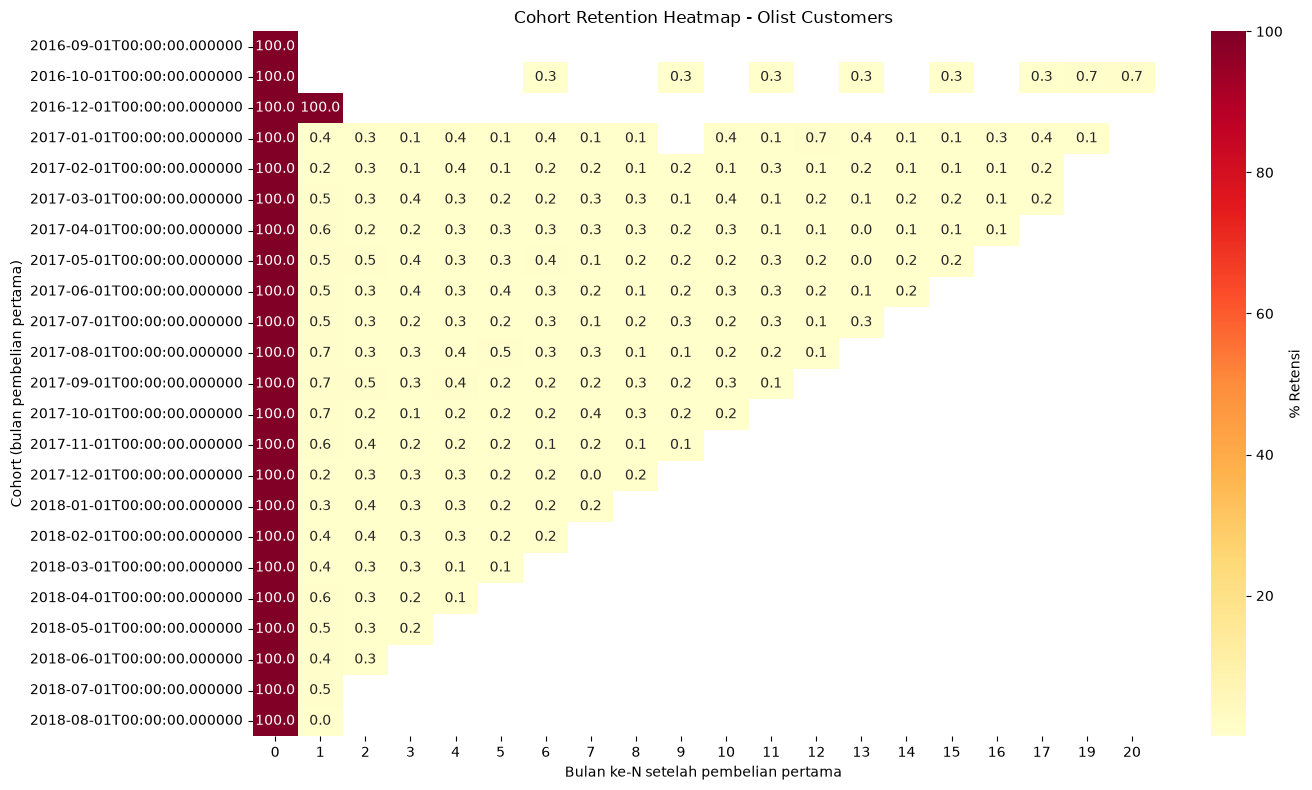

In [5]:
import pandas as pd

pivot = cohort_retention.pivot(
    index="cohort_month", columns="month_number", values="retention_pct"
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "% Retensi"})
plt.title("Cohort Retention Heatmap - Olist Customers")
plt.xlabel("Bulan ke-N setelah pembelian pertama")
plt.ylabel("Cohort (bulan pembelian pertama)")
plt.tight_layout()
plt.savefig("../reports/cohort_heatmap.png", dpi=150)
plt.show()

In [6]:
rfm = con.execute("""
    WITH customer_orders AS (
        SELECT
            c.customer_unique_id,
            o.order_id,
            o.order_purchase_timestamp,
            oi.price + oi.freight_value AS order_value
        FROM olist_orders_dataset o
        JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
        JOIN olist_order_items_dataset oi ON o.order_id = oi.order_id
        WHERE o.order_status NOT IN ('canceled', 'unavailable')
    ),
    rfm_base AS (
        SELECT
            customer_unique_id,
            DATEDIFF('day', MAX(order_purchase_timestamp), (SELECT MAX(order_purchase_timestamp) FROM customer_orders)) AS recency_days,
            COUNT(DISTINCT order_id) AS frequency,
            SUM(order_value) AS monetary
        FROM customer_orders
        GROUP BY 1
    ),
    rfm_scored AS (
        SELECT
            *,
            NTILE(5) OVER (ORDER BY recency_days DESC) AS r_score,
            NTILE(5) OVER (ORDER BY frequency ASC) AS f_score,
            NTILE(5) OVER (ORDER BY monetary ASC) AS m_score
        FROM rfm_base
    )
    SELECT
        *,
        CASE
            WHEN r_score >= 4 AND f_score >= 4 AND m_score >= 4 THEN 'Champion'
            WHEN r_score >= 3 AND f_score >= 3 THEN 'Loyal Customer'
            WHEN r_score >= 4 AND f_score <= 2 THEN 'New Customer'
            WHEN r_score <= 2 AND f_score >= 3 THEN 'At Risk'
            WHEN r_score <= 2 AND f_score <= 2 AND m_score <= 2 THEN 'Lost'
            ELSE 'Regular'
        END AS segment
    FROM rfm_scored
""").df()

rfm["segment"].value_counts()

segment
Loyal Customer    35366
Regular           19248
At Risk           14093
Lost              10087
New Customer       8659
Champion           7530
Name: count, dtype: int64

In [7]:
from pathlib import Path

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(exist_ok=True)

monthly_revenue.to_csv(PROCESSED_DIR / "monthly_revenue.csv", index=False)
cohort_retention.to_csv(PROCESSED_DIR / "cohort_retention.csv", index=False)
rfm.to_csv(PROCESSED_DIR / "rfm_segmentation.csv", index=False)

print("Exported:", list(PROCESSED_DIR.glob("*.csv")))

Exported: [WindowsPath('d:/Albert/Proyek/ecommerce-customer-retention-analysis/data/processed/cohort_retention.csv'), WindowsPath('d:/Albert/Proyek/ecommerce-customer-retention-analysis/data/processed/monthly_revenue.csv'), WindowsPath('d:/Albert/Proyek/ecommerce-customer-retention-analysis/data/processed/rfm_segmentation.csv')]
